In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [148]:
climate_change_data = pd.read_csv("data/climate_change_dataset.csv")

In [149]:
climate_change_data = climate_change_data.rename(columns = {'Avg Temperature (°C)': 'Avg_Temperature', 'CO2 Emissions (Tons/Capita)': 'CO2_Emissions', 'Sea Level Rise (mm)': 'Sea_Level_Rise', 'Rainfall (mm)': 'Rainfall', 'Renewable Energy (%)': 'Renewable_Energy', 'Extreme Weather Events':  'Extreme_Weather_Events', 'Forest Area (%)': 'Forest_Area'})

In [150]:
climate_change_data.columns

Index(['Year', 'Country', 'Avg_Temperature', 'CO2_Emissions', 'Sea_Level_Rise',
       'Rainfall', 'Population', 'Renewable_Energy', 'Extreme_Weather_Events',
       'Forest_Area'],
      dtype='object')

In [151]:
old = climate_change_data[climate_change_data.Year < 2011]

In [152]:
old.loc[old.CO2_Emissions.nlargest(10).index]

,Year,Country,Avg_Temperature,CO2_Emissions,Sea_Level_Rise,Rainfall,Population,Renewable_Energy,Extreme_Weather_Events,Forest_Area
212,2000,France,12.6,19.9,1.3,1056,400673293,29.6,14,41.8
312,2007,Argentina,7.7,19.9,1.6,918,203114192,16.9,10,58.7
628,2007,Brazil,25.3,19.9,2.3,2051,196111561,39.9,3,24.0
140,2008,China,34.8,19.8,2.8,904,1119409767,20.2,9,53.5
515,2000,Indonesia,26.7,19.8,1.8,1807,540634691,27.9,11,34.5
616,2006,USA,23.5,19.8,2.1,2853,629814899,7.6,12,70.0
58,2002,Germany,8.1,19.7,1.8,2905,1254853974,37.3,10,28.1
821,2003,India,7.7,19.6,3.0,600,142785204,36.2,4,53.3
635,2006,UK,12.8,19.5,1.2,1962,444312143,5.9,13,34.6
54,2006,Brazil,32.2,19.4,3.8,2626,1155260147,25.5,1,58.8


In [153]:
climate_change_data = climate_change_data.drop_duplicates(subset = ['Year', 'Country'])

In [154]:
climate_change_data_2023 = climate_change_data[climate_change_data.Year == 2023]
top_three_poluters_2023 = climate_change_data_2023.loc[climate_change_data_2023.CO2_Emissions.nlargest(3).index]
top_three_clean_2023 = climate_change_data_2023.loc[climate_change_data_2023.CO2_Emissions.nsmallest(3).index]

In [155]:
top_three_poluters_2023

,Year,Country,Avg_Temperature,CO2_Emissions,Sea_Level_Rise,Rainfall,Population,Renewable_Energy,Extreme_Weather_Events,Forest_Area
97,2023,USA,6.2,18.6,4.4,1806,487618104,21.9,8,12.1
122,2023,Argentina,30.2,18.1,4.4,2930,542661199,32.7,12,64.1
15,2023,India,31.0,17.6,2.0,2444,365927452,25.1,8,20.6


In [156]:
top_three_clean_2023

,Year,Country,Avg_Temperature,CO2_Emissions,Sea_Level_Rise,Rainfall,Population,Renewable_Energy,Extreme_Weather_Events,Forest_Area
493,2023,Japan,21.9,4.9,3.2,2135,760660662,19.0,11,49.7
203,2023,China,22.5,6.6,3.8,1088,554504868,16.4,13,67.7
281,2023,UK,33.5,9.1,4.2,534,828538833,14.3,10,53.8


In [157]:
usa_data = climate_change_data[climate_change_data.Country == "USA"]
usa_data = usa_data.sort_values(by = "Year")
japan_data = climate_change_data[climate_change_data.Country == "Japan"]
japan_data = japan_data.sort_values(by = "Year")

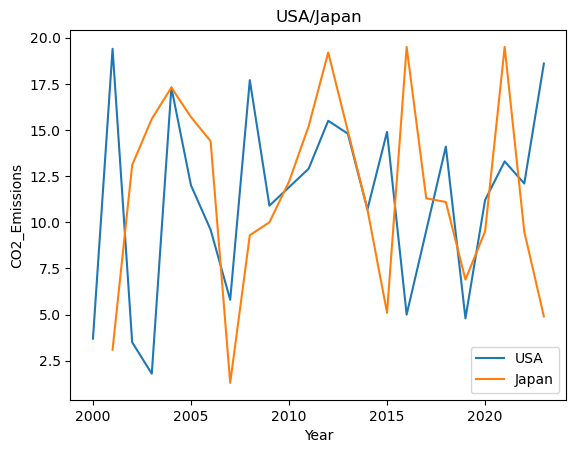

In [163]:
plt.plot(usa_data.Year, usa_data.CO2_Emissions, label = "USA")
plt.plot(japan_data.Year, japan_data.CO2_Emissions, label = "Japan")
plt.xlabel("Year")
plt.ylabel("CO2_Emissions")
plt.title("USA/Japan")
plt.legend()
plt.show()

In [125]:
np.corrcoef(usa_data.Year, usa_data.CO2_Emissions)

array([[1.        , 0.23608181],
       [0.23608181, 1.        ]])

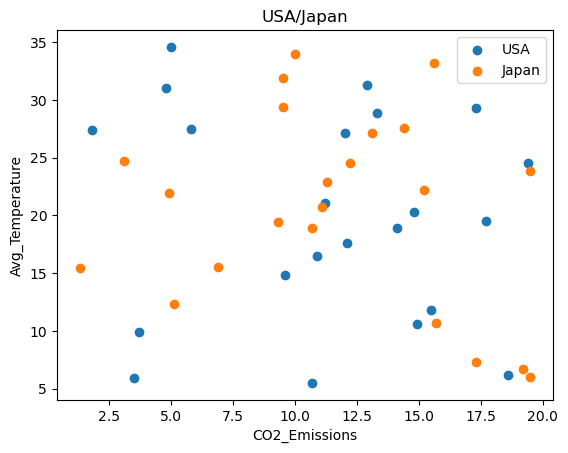

In [165]:
plt.scatter(usa_data.CO2_Emissions, usa_data.Avg_Temperature, label = "USA")
plt.scatter(japan_data.CO2_Emissions, japan_data.Avg_Temperature, label = "Japan")
plt.xlabel("CO2_Emissions")
plt.ylabel("Avg_Temperature")
plt.title("USA/Japan")
plt.legend()
plt.show()

In [167]:
(np.corrcoef(usa_data.CO2_Emissions, usa_data.Avg_Temperature), np.corrcoef(japan_data.CO2_Emissions, japan_data.Avg_Temperature))

(array([[ 1.        , -0.11299801],
        [-0.11299801,  1.        ]]),
 array([[ 1.        , -0.21153932],
        [-0.21153932,  1.        ]]))

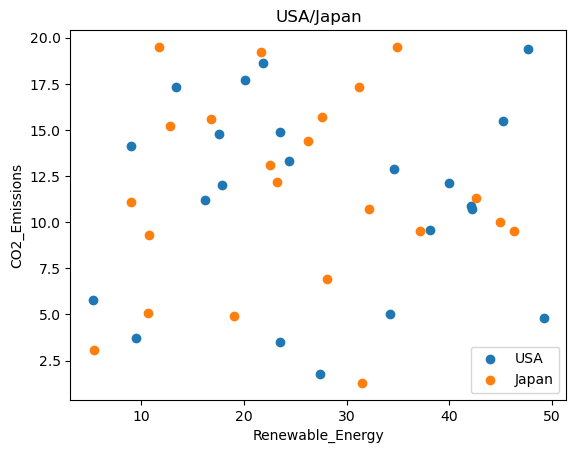

In [166]:
plt.scatter(usa_data.Renewable_Energy, usa_data.CO2_Emissions, label = "USA")
plt.scatter(japan_data.Renewable_Energy, japan_data.CO2_Emissions, label = "Japan")
plt.xlabel("Renewable_Energy")
plt.ylabel("CO2_Emissions")
plt.title("USA/Japan")
plt.legend()
plt.show()

In [168]:
(np.corrcoef(usa_data.Renewable_Energy, usa_data.CO2_Emissions), np.corrcoef(japan_data.Renewable_Energy, japan_data.CO2_Emissions))

(array([[1.        , 0.03312103],
        [0.03312103, 1.        ]]),
 array([[1.        , 0.04591324],
        [0.04591324, 1.        ]]))

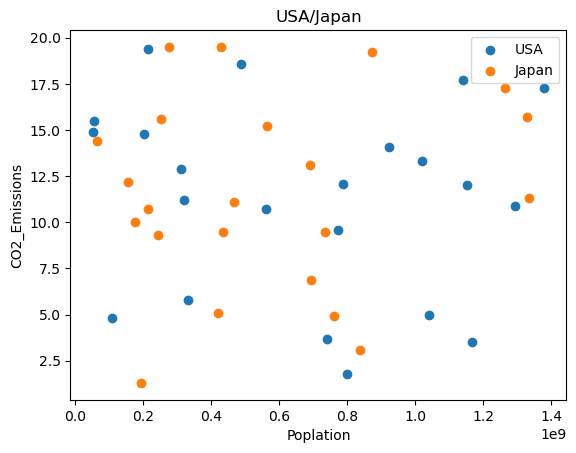

In [169]:
plt.scatter(usa_data.Population, usa_data.CO2_Emissions, label = "USA")
plt.scatter(japan_data.Population, japan_data.CO2_Emissions, label = "Japan")
plt.xlabel("Poplation")
plt.ylabel("CO2_Emissions")
plt.title("USA/Japan")
plt.legend()
plt.show()

In [170]:
(np.corrcoef(usa_data.Population, usa_data.CO2_Emissions), np.corrcoef(japan_data.Population, japan_data.CO2_Emissions))

(array([[ 1.        , -0.12077983],
        [-0.12077983,  1.        ]]),
 array([[1.       , 0.1248888],
        [0.1248888, 1.       ]]))